# AG-HYPOPT · Trial 19

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eighteen trials recorded, objective order: trial_09 0.1657 (BEST), trial_14 0.1679, trial_17 0.1816, trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_18 0.1999, trial_15 0.2046, trial_16 0.2058, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, with large run-to-run scatter even for near-identical configs. The sweet-spot band (high sigma_ref ~22-25, low lr_mu ~5-7, high lr_gamma ~0.85-0.92, moderate anneal ~0.39-0.6) holds all the top results. TPE (18/5) is exploiting. Two trials remain before the cap. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_19'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (18/5 trials)
ID |     ei | params
 1 | 2.7718 | {"gamma_anneal": 0.7073117932129258, "lr_gamma": 0.8726358179049436, "lr_mu": 5.0, "sigma_ref": 22.88620287467156}
 2 | 3.0629 | {"gamma_anneal": 0.4516136810988214, "lr_gamma": 0.8572103903310909, "lr_mu": 5.0, "sigma_ref": 25.0}
 3 | 2.7048 | {"gamma_anneal": 0.5239612719690884, "lr_gamma": 0.8581207119663098, "lr_mu": 7.241091964203262, "sigma_ref": 21.75428784087046}
 4 | 2.6177 | {"gamma_anneal": 0.3685832756682727, "lr_gamma": 0.8814642504207109, "lr_mu": 5.686076019734757, "sigma_ref": 19.543484265874945}
 5 | 3.0205 | {"gamma_anneal": 0.6128921159999896, "lr_gamma": 0.8873864996441735, "lr_mu": 5.0, "sigma_ref": 11.799510040616857}
 6 | 2.1503 | {"gamma_anneal": 0.6231773342772164, "lr_gamma": 0.9175357548257158, "lr_mu": 6.896983039334876, "sigma_ref": 25.0}
 7 | 0.7451 | {"gamma_anneal": 0.6205891639299375, "lr_gamma": 0.7772107162451904, "lr_mu": 5.642900719269237, "sigma_ref": 25.0}
 8 | 1.8168 | {"gamma_annea

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (18/5) ranks by expected improvement. The highest-EI candidate is candidate 2 (EI 3.06): gamma_anneal 0.452, lr_gamma 0.857, lr_mu 5.0, sigma_ref 25.0 -- squarely in the sweet spot (high sigma_ref at the 25.0 boundary, low lr_mu, high lr_gamma, moderate anneal), matching the profiles of the best trials 09/14/17. The runner-up candidate 5 (EI 3.02) is similar but drops sigma_ref to 11.8; candidate 1 (EI 2.77) pushes anneal to 0.707. With the top-EI pick the cleanest continuation of the sweet spot, the choice is clear. I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # highest-EI TPE pick, in the sweet spot


chosen: {'gamma_anneal': 0.4516136810988214, 'lr_gamma': 0.8572103903310909, 'lr_mu': 5.0, 'sigma_ref': 25.0}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 3.78 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.65 | γ 8.5 -> 6.03 | NLL 2.93


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.33 | γ 14.1 -> 13.70 | NLL 3.13


Running 3nW Trans100 ... 

μ 175.71 -> 87.37 | γ 14.1 -> 14.11 | NLL 3.28



Total: 2.5 min


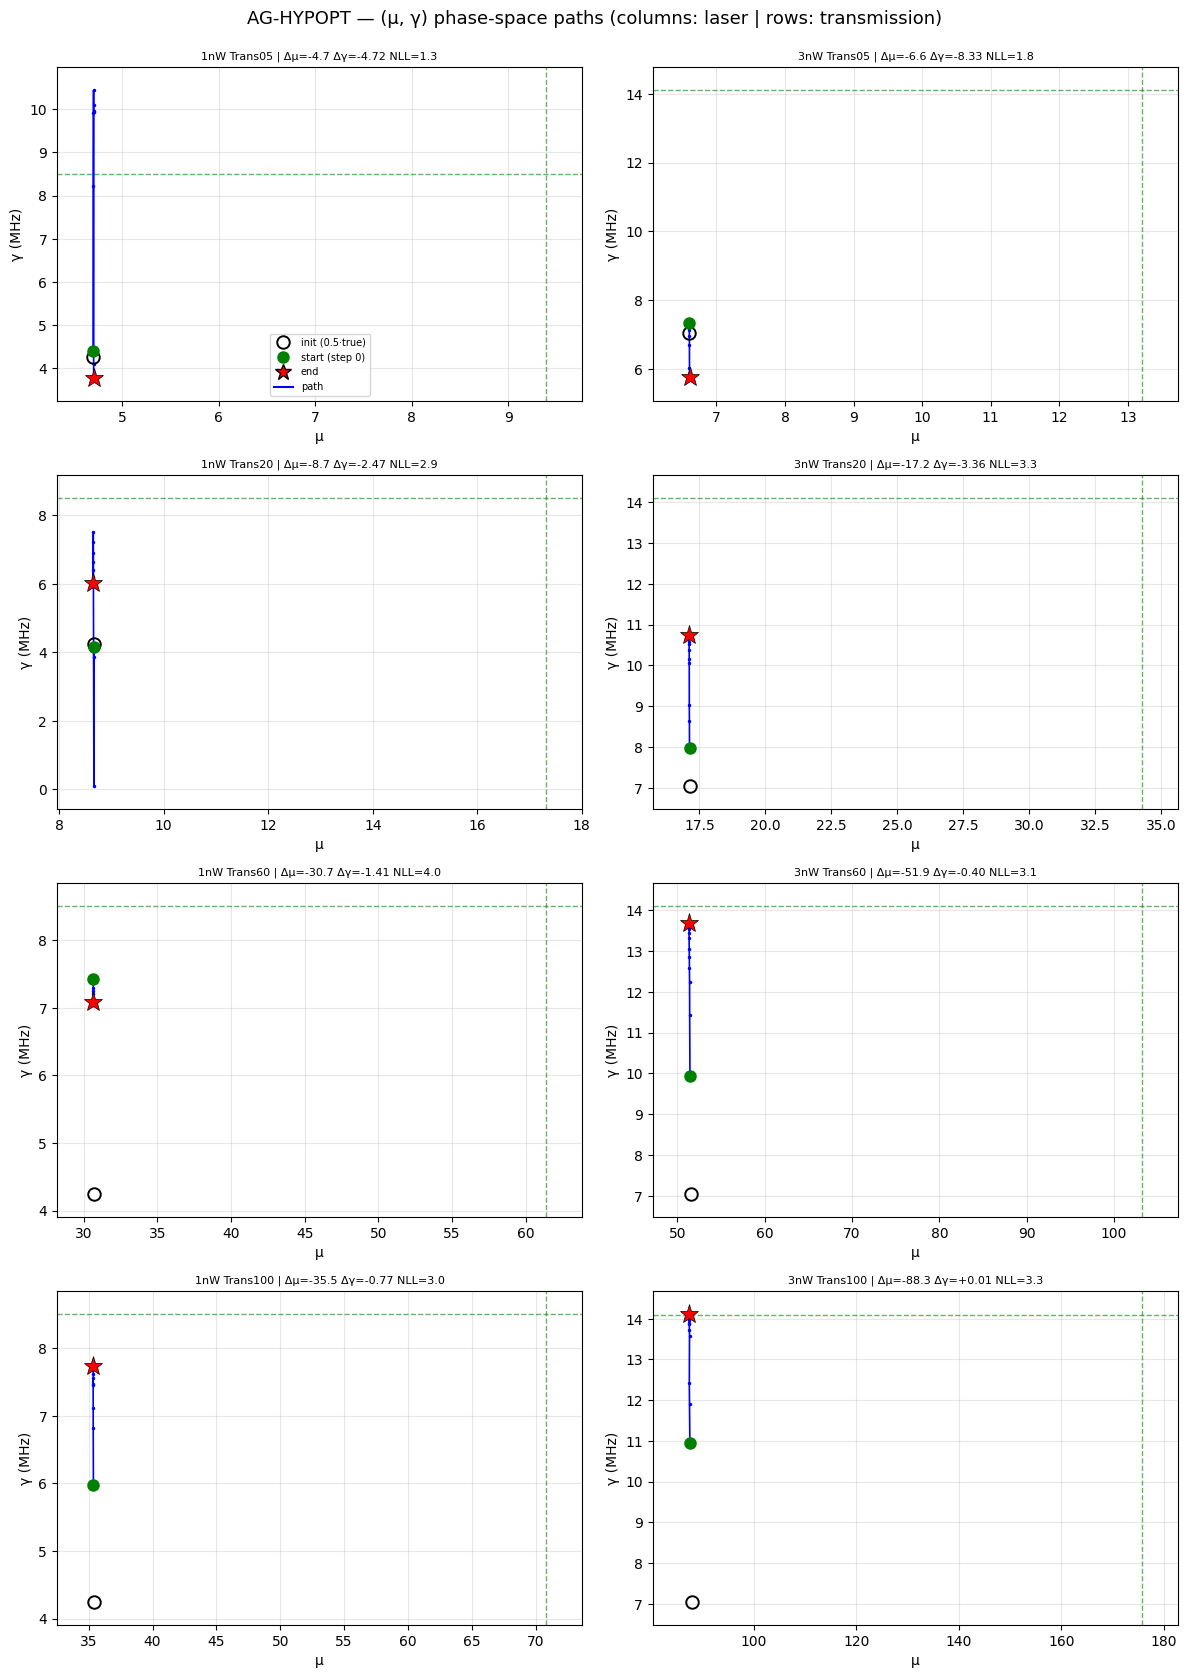

trial finished in 2.5 min
objective = 0.1777 ± 0.0307
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50    3.78   -55.5
1nW Trans20    17.32    8.65   -50.0 |     8.50    6.03   -29.0
1nW Trans60    61.37   30.64   -50.1 |     8.50    7.09   -16.6
1nW Trans100   70.82   35.36   -50.1 |     8.50    7.73    -9.1
3nW Trans05    13.20    6.61   -49.9 |    14.10    5.77   -59.1
3nW Trans20    34.28   17.11   -50.1 |    14.10   10.74   -23.8
3nW Trans60   103.20   51.33   -50.3 |    14.10   13.70    -2.8
3nW Trans100  175.71   87.37   -50.3 |    14.10   14.11    +0.1

μ: RMSE 40.517 (rel 50.1%, bias -30.441) | γ: RMSE 3.740 (rel 32.3%, bias -2.682)


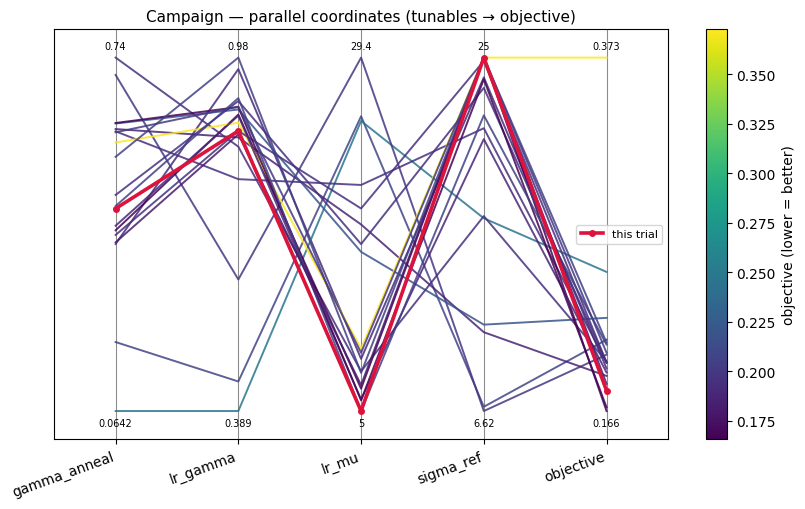

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 19, fourteenth TPE-driven trial; highest-EI pick, in the sweet spot: sigma_ref 25.0, lr_mu 5.0, lr_gamma 0.857, gamma_anneal 0.452. Result: objective 0.1777 +/- 0.0307 -- the THIRD-best of the campaign (behind trial_09 0.1657 and trial_14 0.1679); runtime 2.5 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.3; mu RMSE 40.52, relative 50.1%). gamma_fit: high transmission excellent (3 nW Trans100 +0.1%, Trans60 -2.8%; 1 nW Trans100 -9.1%) and low transmission partly improved (1 nW Trans20 -29.0%, 3 nW Trans05 -59.1%), though 1 nW Trans05 remains -55.5%; gamma RMSE 3.74 (relative 32.3%). So the sweet-spot recipe again produced a top-three result.

**Summary:** Trial 19 (sigma_ref 25.0, lr_mu 5.0, lr_gamma 0.857, gamma_anneal 0.452) -> objective 0.1777 +/- 0.0307, third best; sweet-spot recipe with 3 nW Trans100 gamma essentially exact (+0.1%).
**Key insight:** In this late TPE phase the sweet-spot band now holds four of the five best trials (09, 14, 17, 19), confirming sigma_ref ~25 / low lr_mu / high lr_gamma / moderate anneal as the campaign's best region, while the residual low-transmission gamma error keeps the objective off zero.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 19 (sigma_ref 25.0, lr_mu 5.0, lr_gamma 0.857, gamma_anneal 0.452): objective 0.1777 +/- 0.0307, third best; sweet-spot recipe with 3 nW Trans100 gamma essentially exact (+0.1%)'
KEY_INSIGHT = 'The sweet-spot band now holds four of the five best trials (09, 14, 17, 19), confirming sigma_ref~25 / low lr_mu / high lr_gamma / moderate anneal as the best region, while the residual low-transmission gamma error keeps the objective off zero.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_19 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_20.ipynb. Open it and follow its cells from the top.
